# Imports

In [9]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group, exist_pred

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Snapshots

## load data

In [10]:
root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF/results/baselines'
exp_dirs = os.listdir(root)
exp_dirs = [os.path.join(root, exp_dir) for exp_dir in exp_dirs]

params = ['model', 'pred_len', 'data_id', 'learning_rate', 'batch_size', 'patience', 'individual', 'train_epochs', 'lradj']
metric_names = ['mse', 'mae']

df = []
for exp_dir in exp_dirs:
    runned, setting_dir = exist_metric(exp_dir)
    if not runned:
        continue

    config = load_yaml_as_df(os.path.join(setting_dir, 'config.yaml'))
    metric = load_npy(os.path.join(setting_dir, 'metrics.npy'))
    result = config[params]
    result.loc[:, metric_names] = metric[1], metric[0]
    result.loc[:, ['exp_dir']] = exp_dir
    df.append(result)

df = pd.concat(df, ignore_index=True)
df.sort_values(by=['model', 'data_id', 'pred_len'], inplace=True)

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF/stats'
os.makedirs(save_root, exist_ok=True)
df.to_csv(f"{save_root}/baselines_chosen_repro.csv", index=False)

df.head(4)

,model,pred_len,data_id,learning_rate,batch_size,patience,individual,train_epochs,lradj,mse,mae,exp_dir
3,Fredformer,96,ECL,0.01,32,5,0,100,TST,0.161019,0.257592,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
0,Fredformer,192,ECL,0.01,32,5,0,100,TST,0.173585,0.269470,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
1,Fredformer,336,ECL,0.01,32,5,0,100,TST,0.194108,0.290398,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
2,Fredformer,720,ECL,0.01,32,5,0,100,TST,0.234673,0.319385,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...


## load config

In [11]:

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF/stats'
baselines = pd.read_csv(f'{save_root}/baselines_chosen_repro.csv')

save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'
finetunes_best = pd.read_csv(f'{save_root}/finetune_best.csv')

model_list = ['TQNet', 'PDF']

base = baselines.copy()
base = base[
    # ((base.data_id == 'ETTh1') & (base.model.isin(model_list))) |
    # ((base.data_id == 'ETTh2') & (base.model.isin(model_list))) |
    # ((base.data_id == 'ETTm1') & (base.model.isin(model_list))) |
    ((base.data_id == 'ETTm2') & (base.model.isin(model_list))) |
    ((base.data_id == 'ECL') & (base.model.isin(model_list)))
    # ((base.data_id == 'Weather') & (base.model.isin(model_list)))
]

best = finetunes_best.copy()
best = best[
    # ((best.data_id == 'ETTh1') & (best.model.isin(model_list))) |
    # ((best.data_id == 'ETTh2') & (best.model.isin(model_list))) |
    # ((best.data_id == 'ETTm1') & (best.model.isin(model_list))) |
    ((best.data_id == 'ETTm2') & (best.model.isin(model_list))) |
    ((best.data_id == 'ECL') & (best.model.isin(model_list)))
    # ((best.data_id == 'Weather') & (best.model.isin(model_list)))
]


In [12]:
columns = ['model', 'data_id', 'pred_len', 'mse', 'mae']

# df_show = base[columns].copy()
df_show = best[columns].copy()
df_show.sort_values(by=['data_id', 'model', 'pred_len'], inplace=True)
df_show

best

,model,pred_len,data_id,mse,mae,cov,learning_rate,inner_lr,meta_lr,auxi_loss,rec_lambda,auxi_lambda,reg_lambda,lradj,train_epochs,patience,batch_size,auxi_batch_size,warmup_steps,meta_inner_steps,overlap_ratio,num_tasks,max_norm,first_order,dropout,cycle,meta_type,exp_dir
4,TQNet,96,ETTm2,0.170291,0.252600,0.054238,0.0002,0.0002,0.20,MSE,1.0,0.0,0.0,type1,30,5,32,64,500,5,0.0,1,5.0,1,0.50,96,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
5,TQNet,192,ETTm2,0.233855,0.293836,0.070129,0.0002,0.0002,0.20,MSE,1.0,0.0,0.0,type1,30,5,32,64,500,2,0.0,1,5.0,1,0.50,96,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
6,TQNet,336,ETTm2,0.290130,0.331435,0.148422,0.0002,0.0002,0.10,MSE,1.0,0.0,0.0,type1,30,5,32,64,500,4,0.0,3,5.0,1,0.50,96,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
7,TQNet,720,ETTm2,0.386822,0.388532,0.143924,0.0002,0.0002,0.20,MSE,1.0,0.0,0.0,type1,30,5,32,64,500,5,0.0,5,5.0,1,0.50,96,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
16,TQNet,96,ECL,0.134708,0.228838,0.077857,0.0050,0.0050,0.10,MSE,1.0,0.0,0.0,type1,30,5,16,64,300,2,0.0,3,5.0,1,0.00,168,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
17,TQNet,192,ECL,0.153000,0.244973,0.099885,0.0050,0.0050,0.10,MSE,1.0,0.0,0.0,type1,30,5,16,64,300,1,0.0,3,5.0,1,0.00,168,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
18,TQNet,336,ECL,0.169068,0.262404,0.143932,0.0050,0.0050,0.02,MSE,1.0,0.0,0.0,type1,30,5,16,64,300,2,0.0,3,5.0,1,0.00,168,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
19,TQNet,720,ECL,0.201599,0.290306,0.147142,0.0100,0.0100,0.05,MSE,1.0,0.0,0.0,type1,30,5,16,64,300,1,0.0,1,5.0,1,0.00,168,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
40,PDF,96,ETTm2,0.174904,0.262821,0.075271,0.0005,0.0005,0.20,MSE,1.0,0.0,0.0,type1,100,10,32,64,500,1,0.0,3,5.0,1,0.45,24,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...
41,PDF,192,ETTm2,0.242344,0.305705,0.102176,0.0005,0.0005,0.20,MSE,1.0,0.0,0.0,type1,100,10,32,64,500,1,0.0,3,5.0,1,0.60,24,all,/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/P...


## load data

In [15]:
data = {}

print("process baselines ...\n\n")
for i, row in base.iterrows():
    exp_dir = row['exp_dir']
    runned, setting_dir = exist_pred(exp_dir)
    if not runned:
        print(os.path.basename(exp_dir), 'has no prediction!!')
        continue
    else:
        print(os.path.basename(exp_dir), ' ---> processing ...')

    model, data_id, pred_len = row['model'], row['data_id'], row['pred_len']
    inputs = load_npy(os.path.join(setting_dir, 'input.npy'))[..., -1]
    preds = load_npy(os.path.join(setting_dir, 'pred.npy'))[..., -1]
    trues = load_npy(os.path.join(setting_dir, 'true.npy'))[..., -1]

    gt_ = np.concatenate([inputs, trues], axis=1)
    pd_ = np.concatenate([inputs, preds], axis=1)

    del inputs, preds, trues
    data[f"{model}_{data_id}_{pred_len}"] = [gt_, pd_]


print("process finetunes ...\n\n")
for i, row in best.iterrows():
    exp_dir = row['exp_dir']
    runned, setting_dir = exist_pred(exp_dir)
    if not runned:
        print(os.path.basename(exp_dir), 'has no prediction!!')
        continue
    else:
        print(os.path.basename(exp_dir), ' ---> processing ...')

    try:
        model, data_id, pred_len = row['model'], row['data_id'], row['pred_len']
        inputs = load_npy(os.path.join(setting_dir, 'input.npy'))[..., -1]
        preds = load_npy(os.path.join(setting_dir, 'pred.npy'))[..., -1]
        trues = load_npy(os.path.join(setting_dir, 'true.npy'))[..., -1]

        gt_ = np.concatenate([inputs, trues], axis=1)
        pd_ = np.concatenate([inputs, preds], axis=1)

        del inputs, preds, trues
        data[f"{model}_{data_id}_{pred_len}_OT"] = [gt_, pd_]
    except Exception as e:
        print(f"Error processing {os.path.basename(exp_dir)}: {e}")
        continue

process baselines ...


PDF_ECL_96_1.0_0.0_0.0005_type1_100_10_16  ---> processing ...
PDF_ECL_192_1.0_0.0_0.0005_type1_100_10_16  ---> processing ...
PDF_ECL_336_1.0_0.0_0.0005_type1_100_10_16  ---> processing ...
PDF_ECL_720_1.0_0.0_0.0005_type1_100_10_16  ---> processing ...
PDF_ETTm2_96_1.0_0.0_0.0005_type1_100_10_32  ---> processing ...
PDF_ETTm2_192_1.0_0.0_0.0005_type1_100_10_32  ---> processing ...
PDF_ETTm2_336_1.0_0.0_0.0005_type1_100_10_32  ---> processing ...
PDF_ETTm2_720_1.0_0.0_0.0005_type1_100_10_32  ---> processing ...
TQNet_ECL_96_1.0_0.0_0.0005_type1_30_5_16  ---> processing ...
TQNet_ECL_192_1.0_0.0_0.0005_type1_30_5_16  ---> processing ...
TQNet_ECL_336_1.0_0.0_0.0005_type1_30_5_16  ---> processing ...
TQNet_ECL_720_1.0_0.0_0.0005_type1_30_5_16  ---> processing ...
TQNet_ETTm2_96_1.0_0.0_0.0005_type1_30_5_32  ---> processing ...
TQNet_ETTm2_192_1.0_0.0_0.0005_type1_30_5_32  ---> processing ...
TQNet_ETTm2_336_1.0_0.0_0.0005_type1_30_5_32  ---> processing ...
TQNet_

In [16]:
for k, v in data.items():
    if isinstance(v, list):
        print(k, v[0].shape, v[1].shape)
    else:
        print(k, v.shape)

PDF_ECL_96 (5165, 192) (5165, 192)
PDF_ECL_192 (5069, 288) (5069, 288)
PDF_ECL_336 (4925, 432) (4925, 432)
PDF_ECL_720 (4541, 816) (4541, 816)
PDF_ETTm2_96 (11425, 192) (11425, 192)
PDF_ETTm2_192 (11329, 288) (11329, 288)
PDF_ETTm2_336 (11185, 432) (11185, 432)
PDF_ETTm2_720 (10801, 816) (10801, 816)
TQNet_ECL_96 (5165, 192) (5165, 192)
TQNet_ECL_192 (5069, 288) (5069, 288)
TQNet_ECL_336 (4925, 432) (4925, 432)
TQNet_ECL_720 (4541, 816) (4541, 816)
TQNet_ETTm2_96 (11425, 192) (11425, 192)
TQNet_ETTm2_192 (11329, 288) (11329, 288)
TQNet_ETTm2_336 (11185, 432) (11185, 432)
TQNet_ETTm2_720 (10801, 816) (10801, 816)
TQNet_ETTm2_96_OT (11425, 192) (11425, 192)
TQNet_ETTm2_192_OT (11329, 288) (11329, 288)
TQNet_ETTm2_336_OT (11185, 432) (11185, 432)
TQNet_ETTm2_720_OT (10801, 816) (10801, 816)
TQNet_ECL_96_OT (5165, 192) (5165, 192)
TQNet_ECL_192_OT (5069, 288) (5069, 288)
TQNet_ECL_336_OT (4925, 432) (4925, 432)
TQNet_ECL_720_OT (4541, 816) (4541, 816)
PDF_ETTm2_96_OT (11425, 192) (11425, 1

## preprocess

In [41]:
idxs = {}

# for model in ['TQNet']:
#     for data_id in ['ETTm2']:
#         for pl in [336]:
for model in ['TQNet']:
    for data_id in ['ECL']:
        for pl in [192]:
            base_data = {k: v for k, v in data.items() if data_id in k and 'OT' not in k and str(pl) in k and model in k}
            base_data = list(base_data.values())[0]
            base_mse = np.mean(np.square(base_data[0][:, -pl:] - base_data[1][:, -pl:]), axis=1)

            pca_data = {k: v for k, v in data.items() if data_id in k and 'OT' in k and str(pl) in k and model in k}
            pca_data = list(pca_data.values())[0]
            pca_mse = np.mean(np.square(pca_data[0][:, -pl:] - pca_data[1][:, -pl:]), axis=1)
            # 找到pcamse和base mse之间差距最大，并且pcamse较小的index排序
            diff = pca_mse - base_mse
            idx = np.argsort(diff)
            # 选取前50个
            idx = idx[:100]
            pca_min = pca_mse[idx]
            for i in idx:
                print(f'{data_id} {pl} index {i} diff {diff[i]} pca mse {pca_mse[i]} base mse {base_mse[i]}')
            min_idx = np.argsort(pca_min)[0]
            idxs[f'{data_id}_{pl}'] = idx[min_idx]
            print(f'{data_id} {pl} index {idx[min_idx]}')

ECL 192 index 3654 diff -0.48591275824181884 pca mse 0.4684628150305487 base mse 0.9543755732723676
ECL 192 index 411 diff -0.31327717930137916 pca mse 0.3016330675216748 base mse 0.614910246823054
ECL 192 index 1945 diff -0.29964470667337734 pca mse 0.3414063319140212 base mse 0.6410510385873985
ECL 192 index 1944 diff -0.2989772257866323 pca mse 0.3446681111327727 base mse 0.643645336919405
ECL 192 index 1946 diff -0.27475999907343157 pca mse 0.33504756153064436 base mse 0.6098075606040759
ECL 192 index 538 diff -0.2666325528082697 pca mse 0.6130447792360019 base mse 0.8796773320442716
ECL 192 index 3169 diff -0.26640335312339675 pca mse 0.48227686282919885 base mse 0.7486802159525956
ECL 192 index 410 diff -0.264654756573484 pca mse 0.35925801451188594 base mse 0.6239127710853699
ECL 192 index 1947 diff -0.2628959876544189 pca mse 0.2848583654348875 base mse 0.5477543530893064
ECL 192 index 1948 diff -0.25233123161171356 pca mse 0.30213437812412747 base mse 0.554465609735841
ECL 192

In [ ]:

model = 'TQNet'
data_id = 'ECL'
pl = 192
datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_{pl}_OT"]}

mse_base = np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:]))
mse_ot = np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][:, -pl:]))
print(f"TQNet {data_id} {pl} mse_ot {mse_ot} mse_base {mse_base}")

for i in range(0, 10000, 100):
    try:
        # print(f"TQNet {data_id} {pl} index {index}")
        mse_base = np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][i, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][i, -pl:]))
        mse_ot = np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][i, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][i, -pl:]))
        if mse_ot < mse_base:
            print(f"TQNet {data_id} {pl} index {i} mse_ot {mse_ot} mse_base {mse_base}")
            print('\n')
    except Exception as e:
        pass

## plot

TQNet ECL 192 index 1945
0.6410510385873985
0.3414063319140212
PDF ECL 192 index 1945
0.15368119669130223
0.159047202706607


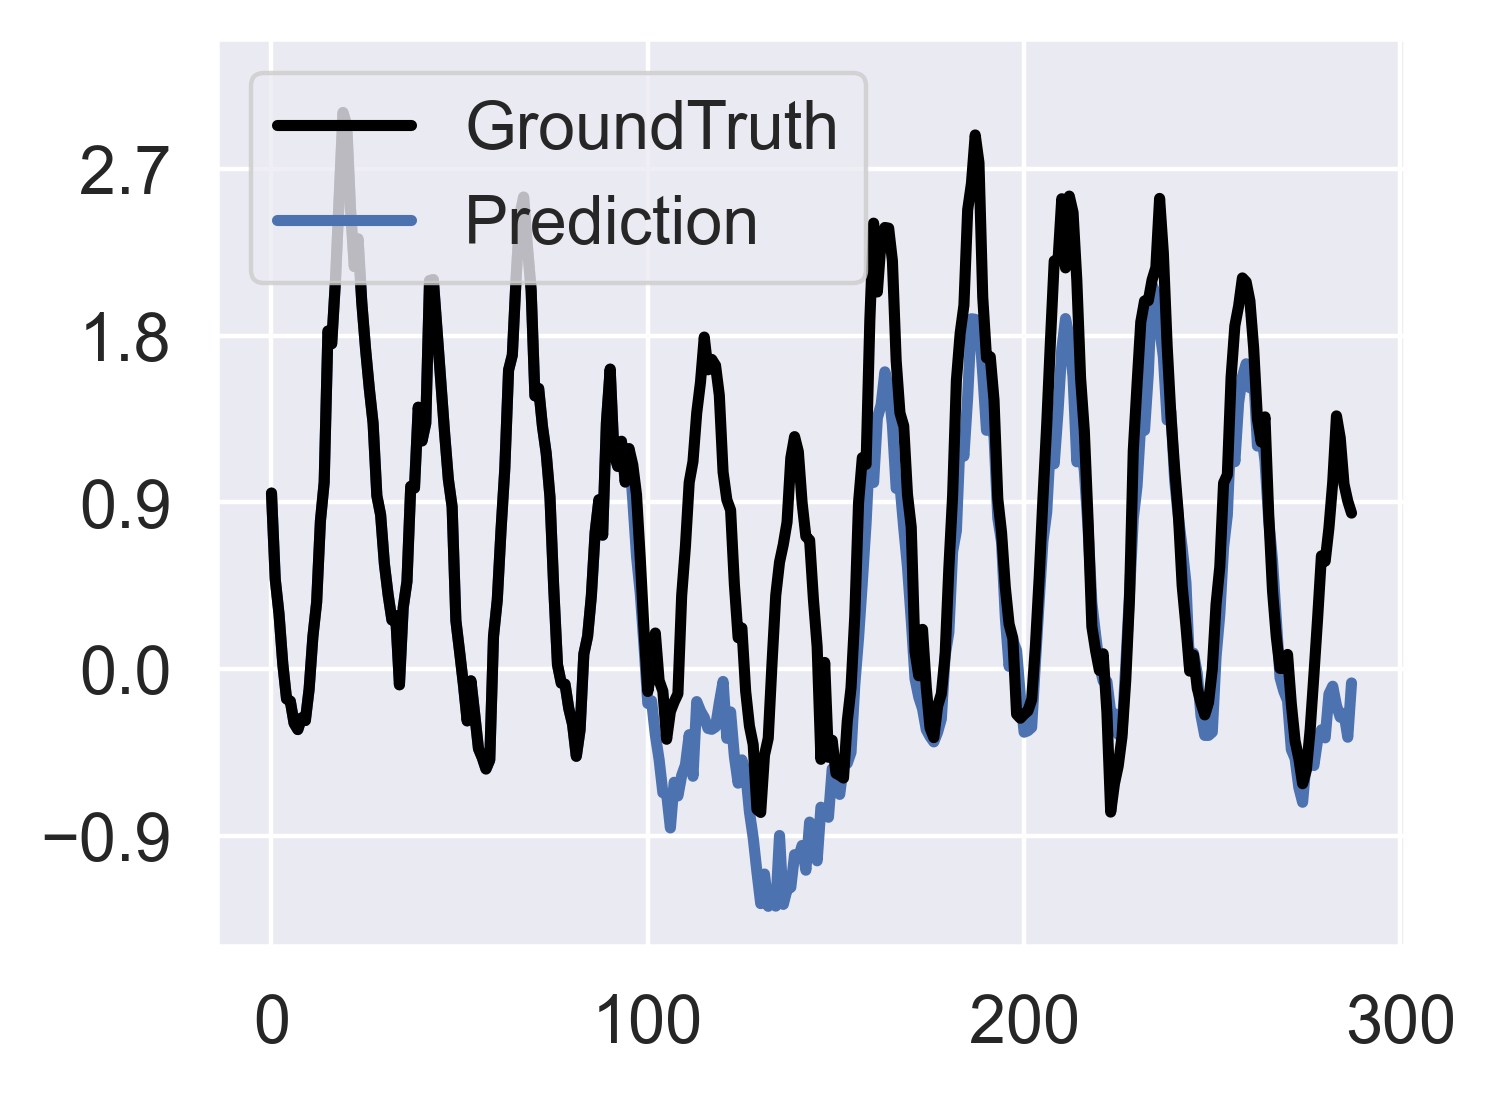

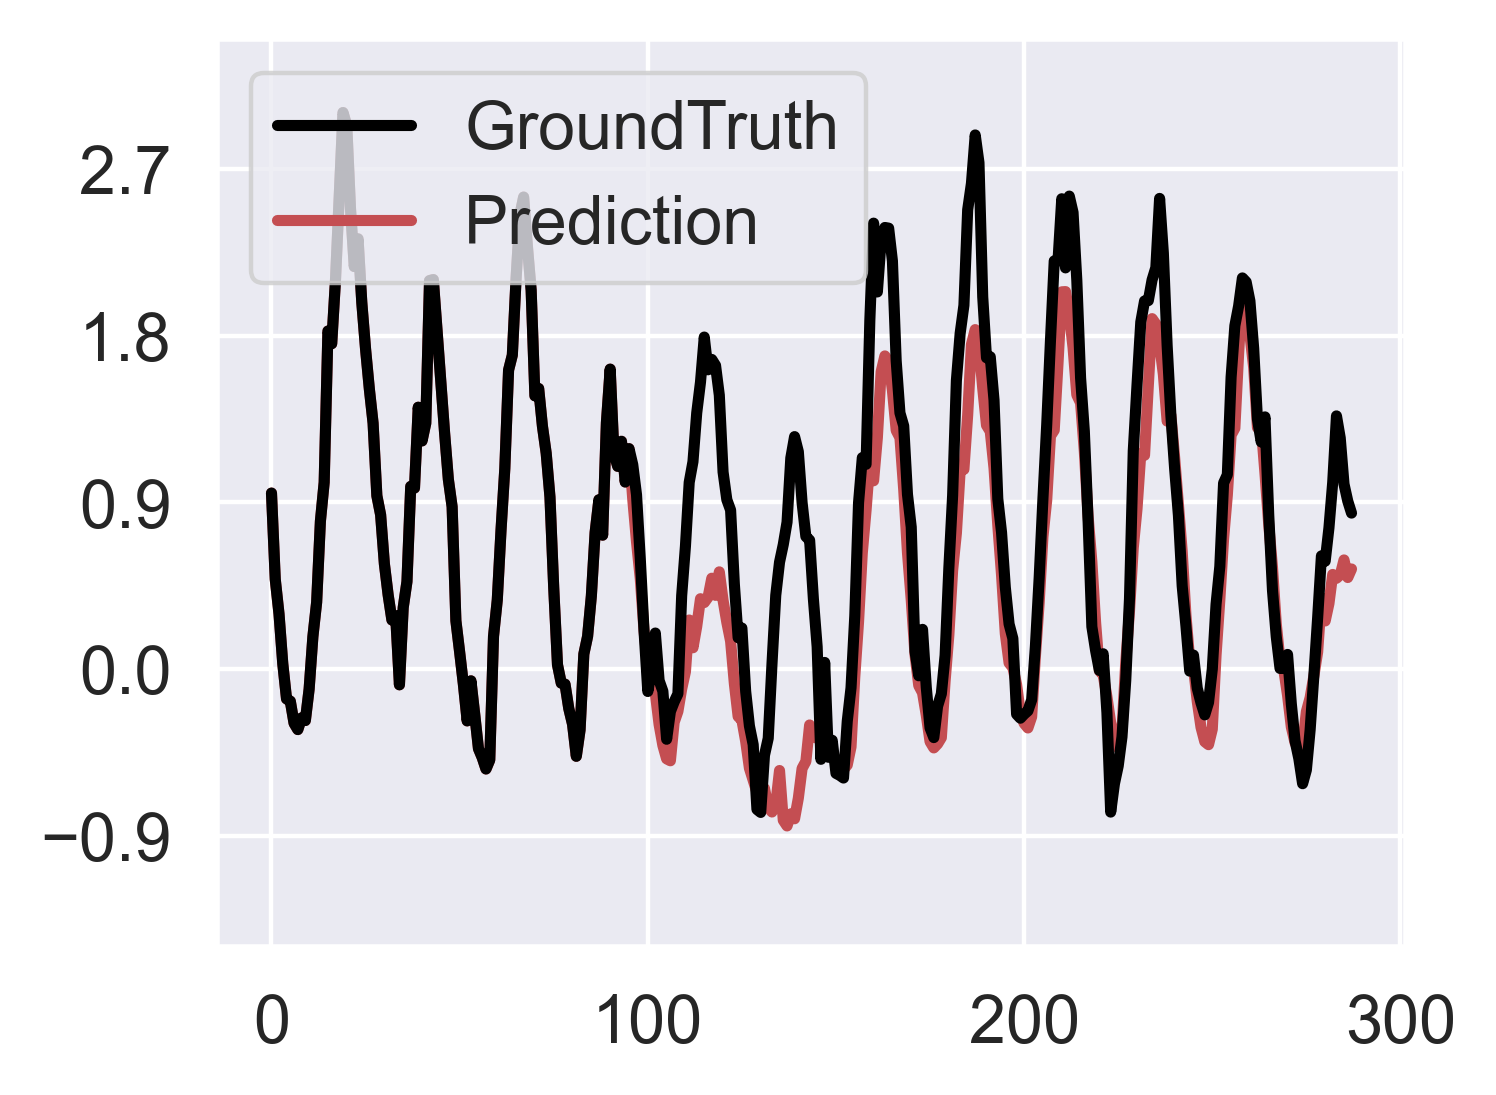

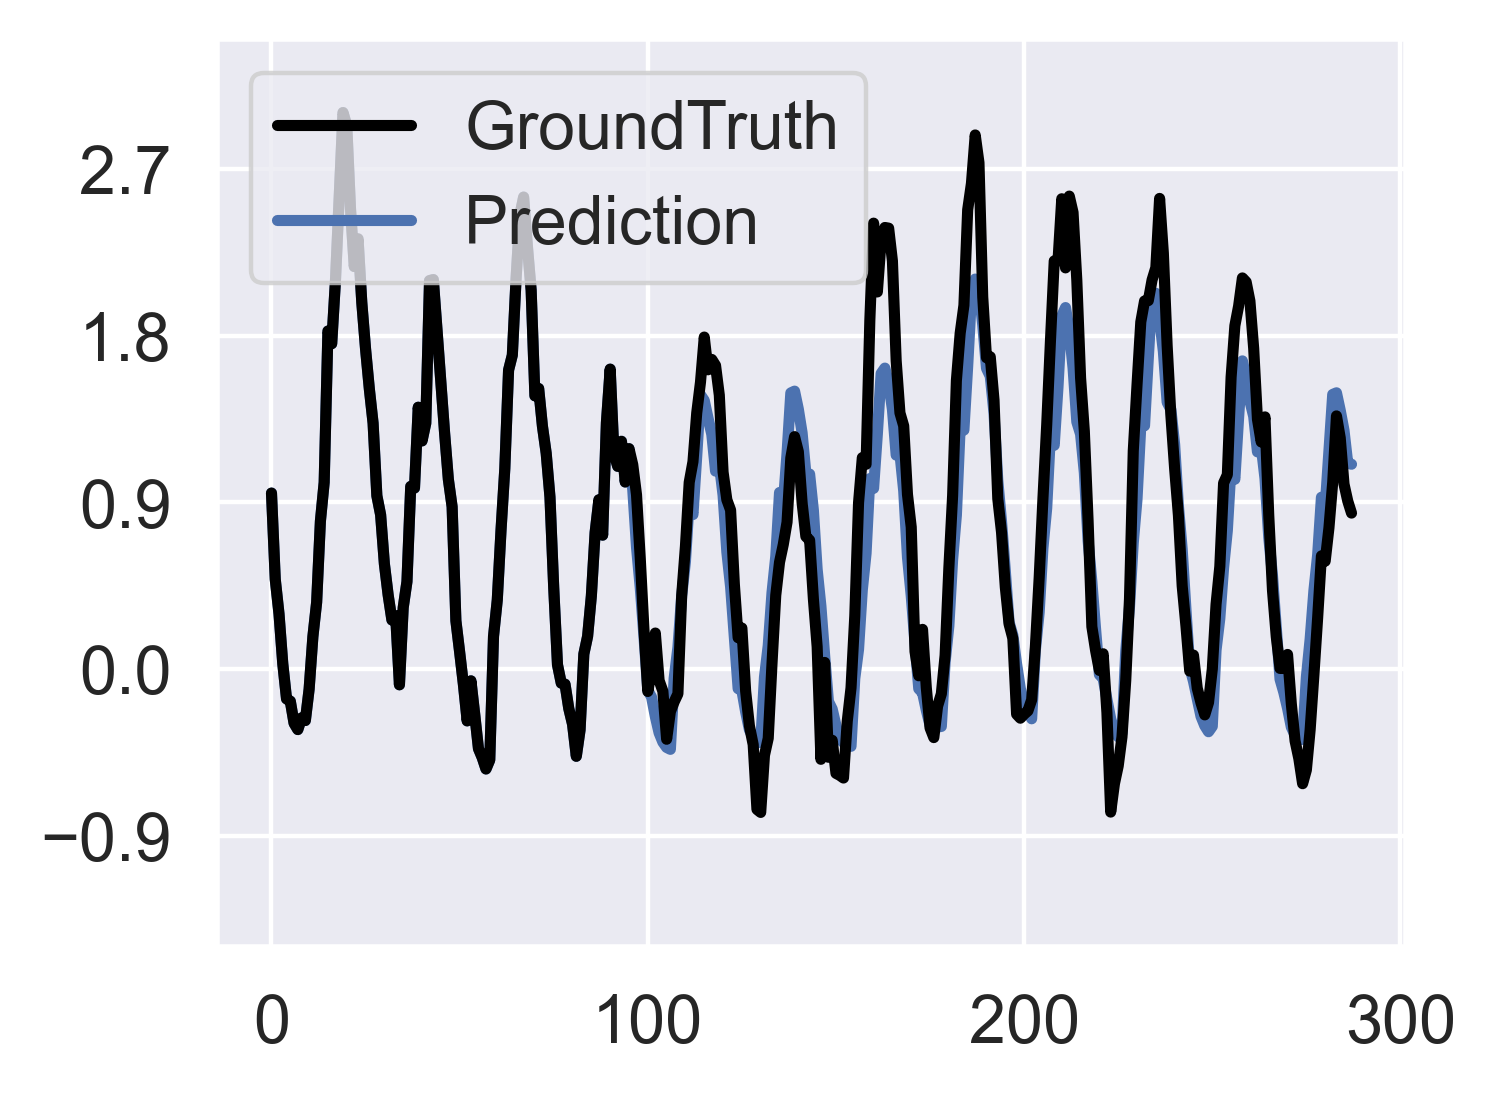

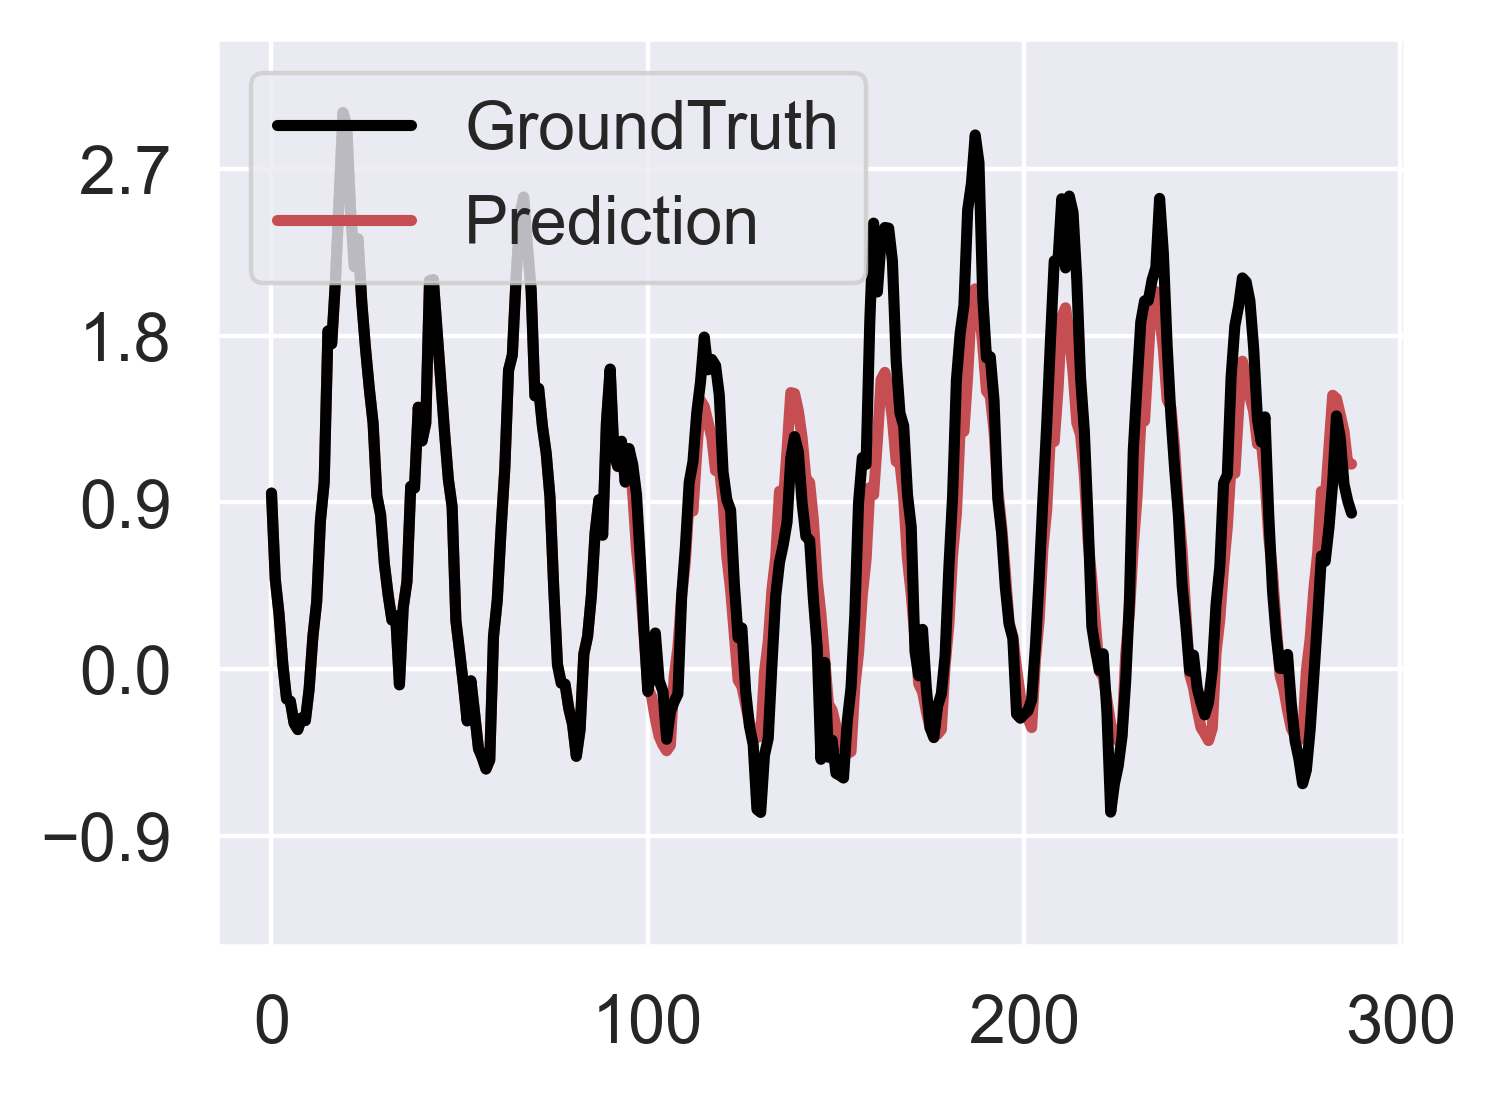

In [65]:
def plot(dataset, model, index, _save_dir, figure_name='predict', ypad=0, loc=None, limit=None, dpi=400, ylim=None, save=True):
    legend_location = 'upper left' if loc is None else loc
    labelsize = 12

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=dpi, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)

    f.add_subplot(1, 1, 1)
    d1 = [v for k, v in dataset.items() if 'OT' not in k]
    true, preds = d1[0][0][index], d1[0][1][index]
    if limit is not None:
        true, preds = true[:limit], preds[:limit]

    plt.plot(true, label='GroundTruth', linewidth=2, color='black', zorder=2)
    plt.plot(preds, label='Prediction', linewidth=2, color=palette[1], zorder=1)
    ax = plt.gca()
    if ypad:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad))  # 小数点后3位数间隔。
    if ylim:
        plt.ylim(ylim)
    plt.legend(ncol=1, loc=legend_location, fontsize=labelsize)
    # plt.title(model, fontsize=14)
    plt.tick_params(labelsize=labelsize)

    plt.tight_layout()
    if save:
        with PdfPages(os.path.join(_save_dir, f"{figure_name}_wo_QDF.pdf")) as pdf:
            pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    else:
        plt.show()


    f = plt.figure(dpi=dpi, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)

    f.add_subplot(1, 1, 1)
    d1 = [v for k, v in dataset.items() if 'OT' in k]
    true, preds = d1[0][0][index], d1[0][1][index]
    if limit is not None:
        true, preds = true[:limit], preds[:limit]

    plt.plot(true, label='GroundTruth', linewidth=2, color='black', zorder=2)
    plt.plot(preds, label='Prediction', linewidth=2, color=palette[0], zorder=1)
    ax = plt.gca()
    if ypad:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad))  # 小数点后3位数间隔。
    if ylim:
        plt.ylim(ylim)
    plt.legend(ncol=1, loc=legend_location, fontsize=labelsize)
    # plt.title(model + ' & PDF', fontsize=14)
    plt.tick_params(labelsize=labelsize)

    plt.tight_layout()
    if save:
        with PdfPages(os.path.join(_save_dir, f"{figure_name}_w_QDF.pdf")) as pdf:
            pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    else:
        plt.show()


figure_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
save_dir = os.path.join(figure_root, 'pred')
os.makedirs(save_dir, exist_ok=True)

DPI = 400

loc = 'lower left'; ylim = [-2, 1]; ypad = 0.5; save = False


# index = 10949; loc = 'lower left'; ylim = [-1.7, 0.1]; ypad = 0.5; save = True
# index = 2255   # x
# index = 8071; loc = 'lower left'; ylim = [-2, 0.2]; ypad = 0.5; save = True
# index = 6726     # x
# index = 2841; loc = 'lower left'; ylim = [-1.7, 0.2]; ypad = 0.5; save = True


# index = 842; loc = 'lower left'; ylim = [-1.2, 1.1]; ypad = 0.5; save = True
# index = 5520; loc = 'upper left'; ylim = [-2.1, 0.1]; ypad = 0.5; save = True
# index = 7727; loc = 'upper left'; ylim = [-2.5, 0.3]; ypad = 0.5; save = True

data_id = 'ETTm2'

pl = 336


# model = 'TQNet'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_{pl}_OT"]}
# print(f"TQNet {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'TQNet_{data_id}_{pl}_{index}', loc=loc, dpi=DPI, ylim=ylim, ypad=ypad, save=save)


# model = 'PDF'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_{pl}_OT"]}
# print(f"PDF {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'PDF_{data_id}_{pl}_{index}', loc=loc, dpi=DPI, ylim=ylim, ypad=ypad, save=save)





# DPI = 400

# # index = 604    # x
# # index = 2452

loc = 'upper left'; ylim = [-1.5, 3.4]; ypad = 1.2; save = False


index = 1945; loc = 'upper left'; ylim = [-1.5, 3.4]; ypad = 0.9; save = True
# index = 411; loc = 'upper left'; ylim = [-2, 4.5]; ypad = 1.2; save = True
# index = 2952; loc = 'upper left'; ylim = [-2.1, 3.5]; ypad = 1.2; save = True


data_id = 'ECL'
pl = 192

model = 'TQNet'
datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_{pl}_OT"]}
print(f"TQNet {data_id} {pl} index {index}")
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][index, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][index, -pl:])))
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][index, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][index, -pl:])))
plot(datap, model, index, save_dir, figure_name=f'TQNet_{data_id}_{pl}_{index}', loc=loc, dpi=DPI, ylim=ylim, ypad=ypad, save=save)


model = 'PDF'
datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_{pl}_OT"]}
print(f"PDF {data_id} {pl} index {index}")
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][index, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][index, -pl:])))
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}_OT"][0][index, -pl:] - datap[f"{model}_{data_id}_{pl}_OT"][1][index, -pl:])))
plot(datap, model, index, save_dir, figure_name=f'PDF_{data_id}_{pl}_{index}', loc=loc, dpi=DPI, ylim=ylim, ypad=ypad, save=save)
